In [41]:
#!pip install -r requirements.txt

In [42]:
# Imports
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
from datetime import timedelta

from scipy import stats
from sklearn import preprocessing
from sklearn.model_selection import (train_test_split, cross_validate,
                                     StratifiedKFold, GridSearchCV, RandomizedSearchCV)
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.base import clone
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.dummy import DummyClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                             average_precision_score, silhouette_score,
                             adjusted_rand_score, RocCurveDisplay,
                             PrecisionRecallDisplay, classification_report)

sns.set_theme(style="whitegrid", palette="muted")


### Data Loading
Download the Portuguese bank-marketing dataset (45,211 clients, 17 columns) and load it as a DataFrame.


In [43]:
def load_data():
    path = kagglehub.dataset_download("prakharrathi25/banking-dataset-marketing-targets")
    df = pd.read_csv(f"{path}/train.csv", sep=';')
    print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns.")
    return df

In [44]:
train_df = load_data()

Dataset loaded: 45211 rows, 17 columns.


### Data Inspection
Review data types, unknown placeholders and IQR outliers before any cleaning.


In [45]:
def get_dataset_summary(df):
    # Performs basic dataset exploration: types, nulls, and 'unknown' values.
    print(f"--- Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns ---")
    
    # Inspect Data Types: Important for determining encoding strategies
    print("\n--- Feature Data Types ---")
    print(df.dtypes)
    
    # Check for standard NaNs: Though this dataset uses 'unknown'
    print("\n--- Standard Missing Values (NaNs) ---")
    print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().any() else "No standard NaNs found.")
    
    # Check for 'unknown' strings (The dataset's specific way of marking missing data)
    print("\n--- 'Unknown' Value Counts per Column ---")
    found_unknown = False
    for col in df.columns:
        # Check if 'unknown' exists in the column
        unknown_count = (df[col] == 'unknown').sum()
        if unknown_count > 0:
            percentage = (unknown_count / len(df)) * 100
            print(f"{col:12}: {unknown_count:>5} values ({percentage:.2f}%)")
            found_unknown = True
            
    if not found_unknown:
        print("No 'unknown' values detected.")

def analyze_outliers(df):
    # Identifies outliers using the IQR method. Calculates the percentage of data points that fall outside the bounds.
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    print("--- Outlier Analysis (IQR Method) ---")
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        percentage = (len(outliers) / len(df)) * 100
        
        print(f"{col:10}: {len(outliers):>5} outliers ({percentage:.2f}%)")

In [46]:
get_dataset_summary(train_df)
analyze_outliers(train_df)

--- Dataset Dimensions: 45211 rows, 17 columns ---

--- Feature Data Types ---
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

--- Standard Missing Values (NaNs) ---
No standard NaNs found.

--- 'Unknown' Value Counts per Column ---
job         :   288 values (0.64%)
education   :  1857 values (4.11%)
contact     : 13020 values (28.80%)
poutcome    : 36959 values (81.75%)
--- Outlier Analysis (IQR Method) ---
age       :   487 outliers (1.08%)
balance   :  4729 outliers (10.46%)
day       :     0 outliers (0.00%)
duration  :  3235 outliers (7.16%)
campaign  :  3064 outliers (6.78%)
pdays     :  8257 outliers (18.26%)
previous  :  8257 outliers (18.26%)


### Exploratory Data Analysis
Distributions, class imbalance and feature–target relationships that motivate the preprocessing choices.


In [47]:
def plot_target_distribution(df):
    # Pie chart showing class imbalance in the target variable.
    plt.figure(figsize=(8, 6))
    counts = df['y'].value_counts()
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', 
            startangle=140, colors=['#ff9999','#66b3ff'], explode=(0.1, 0))
    plt.title('Target Variable: Subscription Success Rate')
    plt.show()

def plot_numeric_distributions(df):
    # Histograms with KDE for all numeric features to inspect skew and spread.
    numeric_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    axes = axes.flatten()
    
    for i, col in enumerate(numeric_cols):
        sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color='teal')
        axes[i].set_title(f'Distribution of {col.capitalize()}')
    
    plt.tight_layout()
    plt.show()

def plot_categorical_proportions(df, cat_col, order=None):
    # Stacked bar chart showing subscription rate per category level.
    fig, ax = plt.subplots(figsize=(12, 6))
    prop_df = pd.crosstab(df[cat_col], df['y'], normalize='index') * 100
    if order:
        prop_df = prop_df.reindex(order)
    prop_df.plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'], ax=ax)
    ax.set_title(f'Subscription Rate by {cat_col.capitalize()}')
    ax.set_ylabel('Percentage %')
    plt.xticks(rotation=45)
    plt.legend(title='Subscribed?', loc='upper right')
    plt.show()

def plot_correlation_heatmap(df):
    # Heatmap of correlations between numeric features to identify multicollinearity.
    plt.figure(figsize=(10, 8))
    numeric_df = df.select_dtypes(include=[np.number])
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap of Numerical Features')
    plt.show()

def plot_duration_impact(df):
    # Boxplot of call duration by subscription outcome on a log scale.
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='y', y='duration', data=df, hue='y', palette='Set2', legend=False)
    plt.yscale('log')
    plt.title('Call Duration by Subscription Outcome (Log Scale)')
    plt.ylabel('Duration (seconds)')
    plt.xlabel('Subscribed?')
    plt.show()

def plot_debt_vs_conversion(df):
    # Stacked bar charts showing subscription rate by housing and personal loan status.
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    pd.crosstab(df['housing'], df['y'], normalize='index').mul(100).plot(
        kind='bar', stacked=True, ax=ax1, color=['#e74c3c', '#2ecc71'])
    ax1.set_title('Subscription Rate by Housing Loan Status')
    
    pd.crosstab(df['loan'], df['y'], normalize='index').mul(100).plot(
        kind='bar', stacked=True, ax=ax2, color=['#e74c3c', '#2ecc71'])
    ax2.set_title('Subscription Rate by Personal Loan Status')
    
    plt.show()

def plot_campaign_efficiency(df):
    # Line plot of conversion rate by number of contacts in this campaign.
    plt.figure(figsize=(12, 6))
    efficiency = df.copy()
    efficiency['y_numeric'] = (efficiency['y'] == 'yes').astype(int)
    efficiency = efficiency.groupby('campaign')['y_numeric'].mean().mul(100).head(10)
    efficiency.plot(kind='line', marker='o', color='purple')
    plt.title('Conversion Rate by Number of Campaign Contacts')
    plt.xlabel('Number of Contacts')
    plt.ylabel('Success Rate (%)')
    plt.grid(True)
    plt.show()

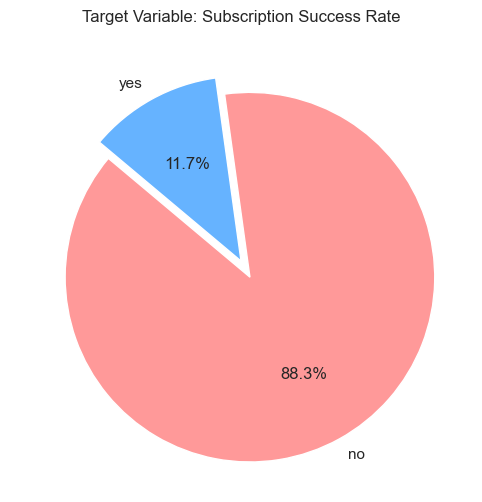

In [48]:
# Class Imbalance (Pie Chart)
plot_target_distribution(train_df)

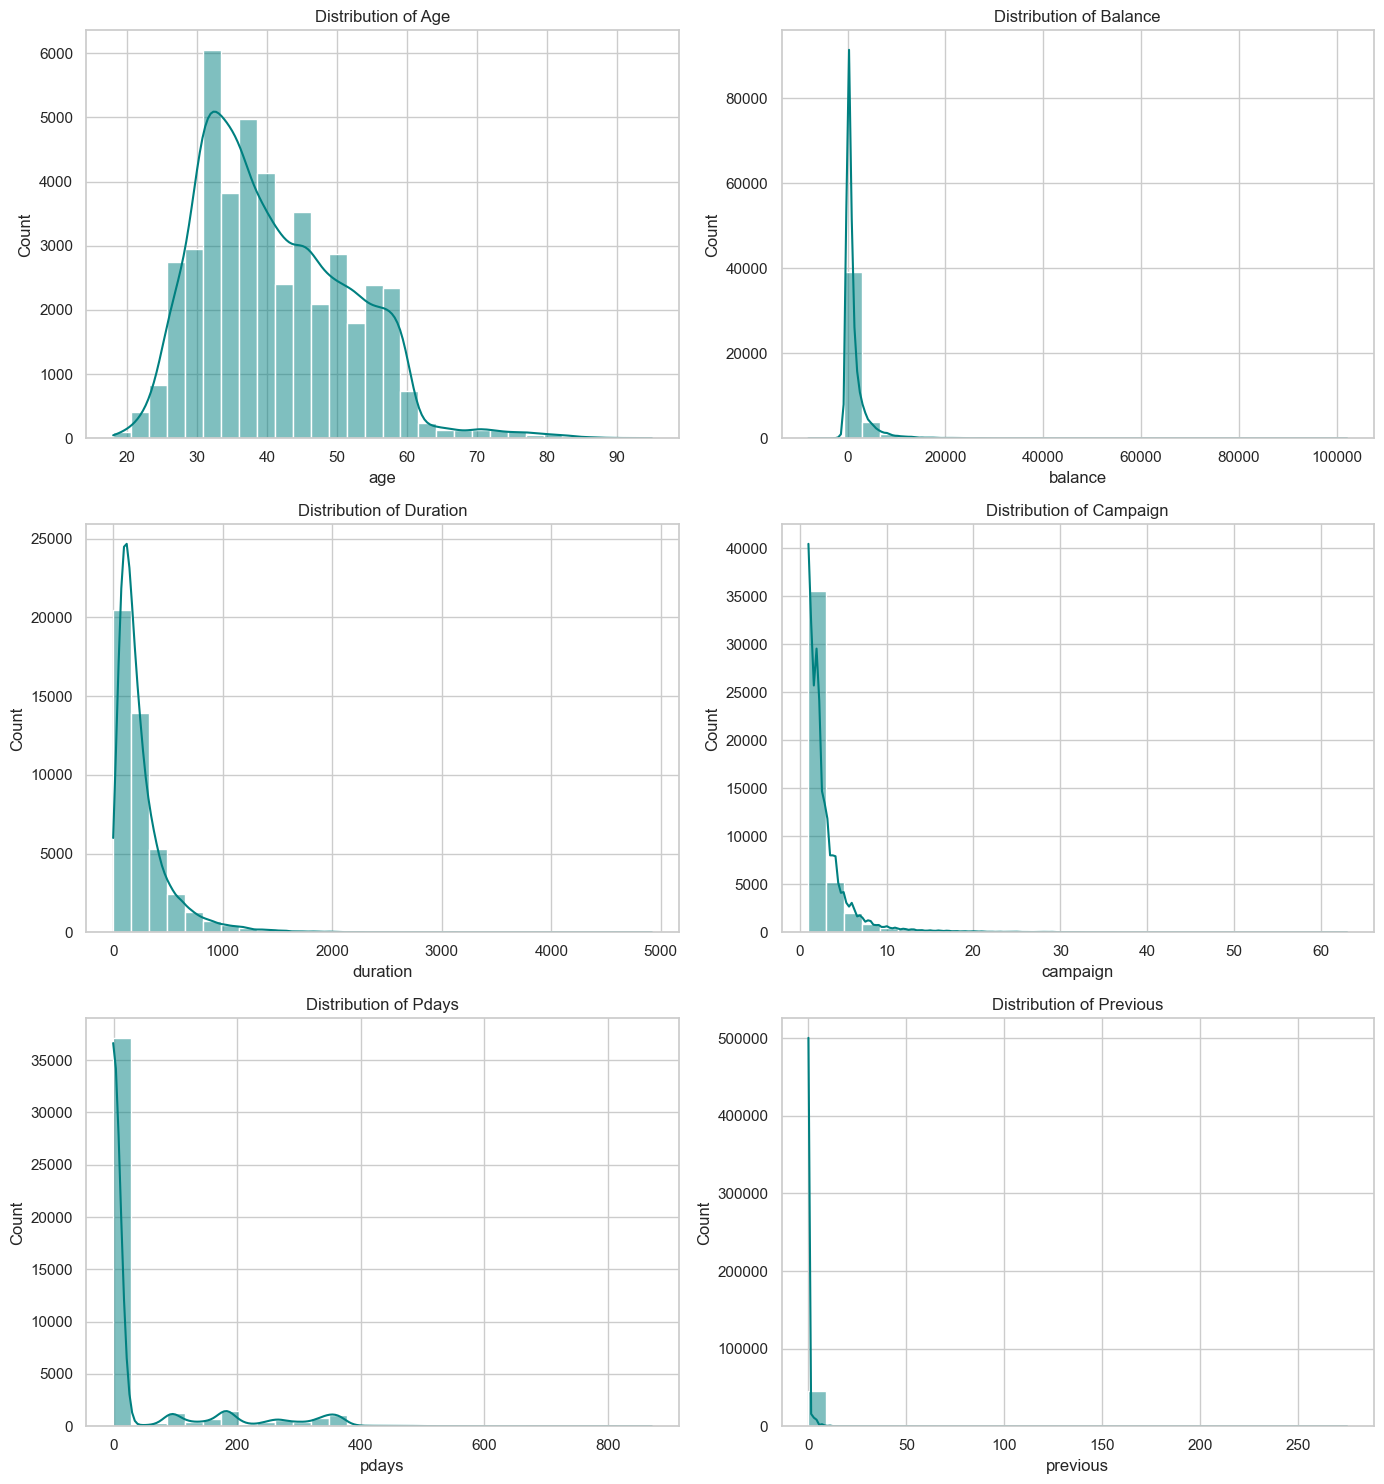

In [49]:
# Numeric Distributions 
plot_numeric_distributions(train_df)

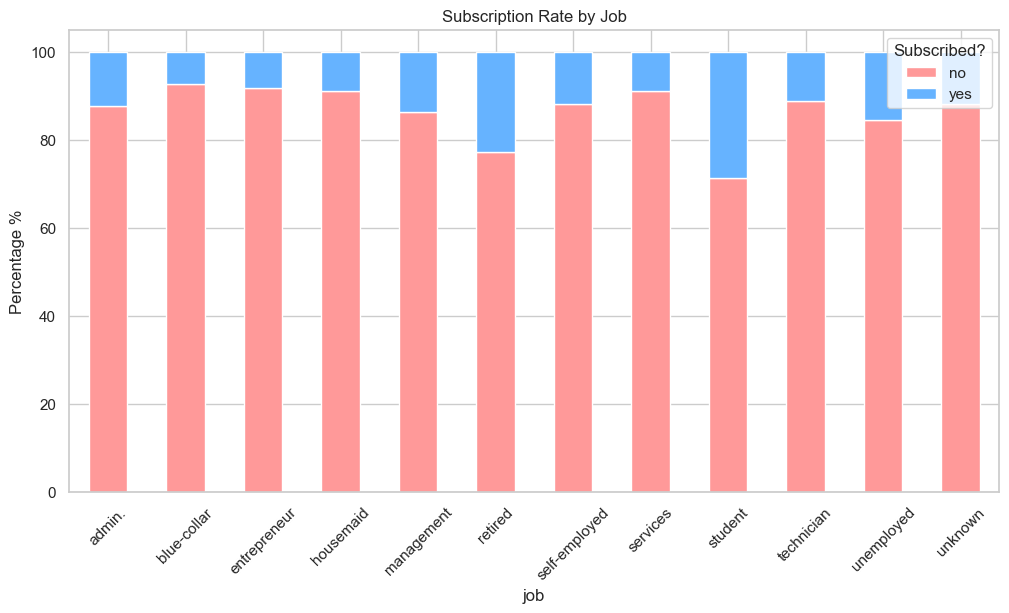

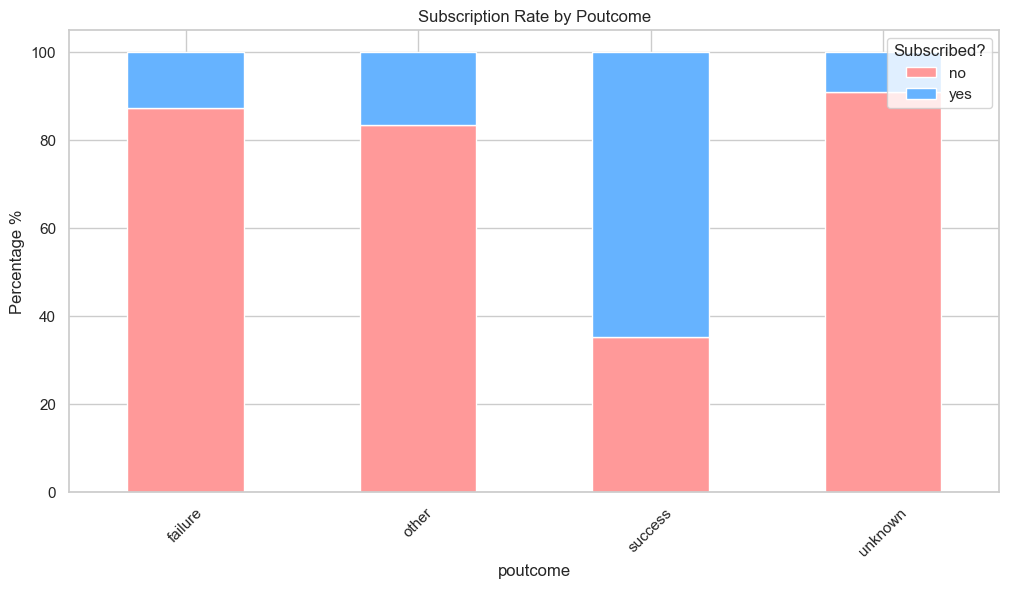

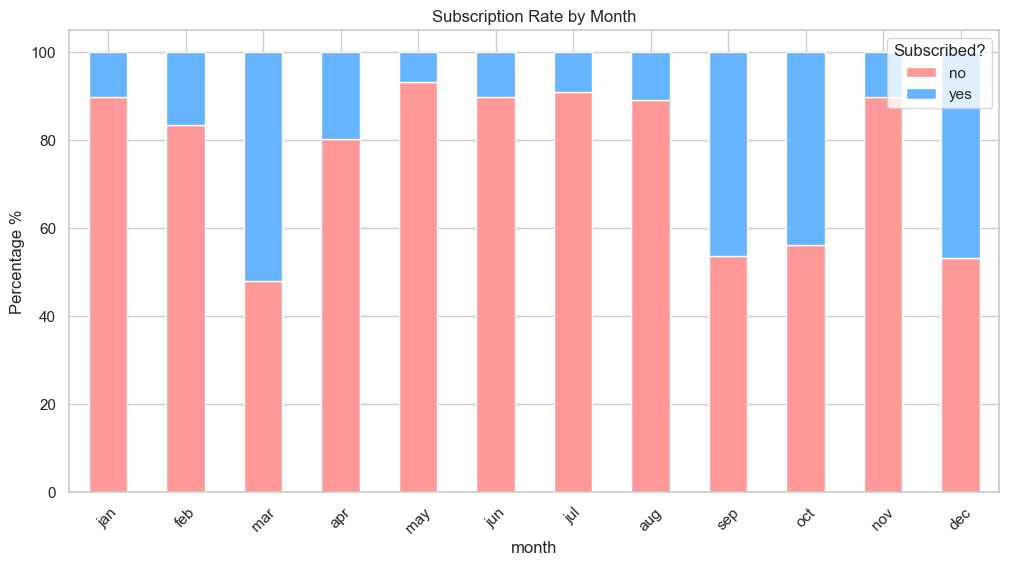

In [50]:
# 3. Categorical Analysis 
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

plot_categorical_proportions(train_df, 'job')
plot_categorical_proportions(train_df, 'poutcome')
plot_categorical_proportions(train_df, 'month', order=month_order)

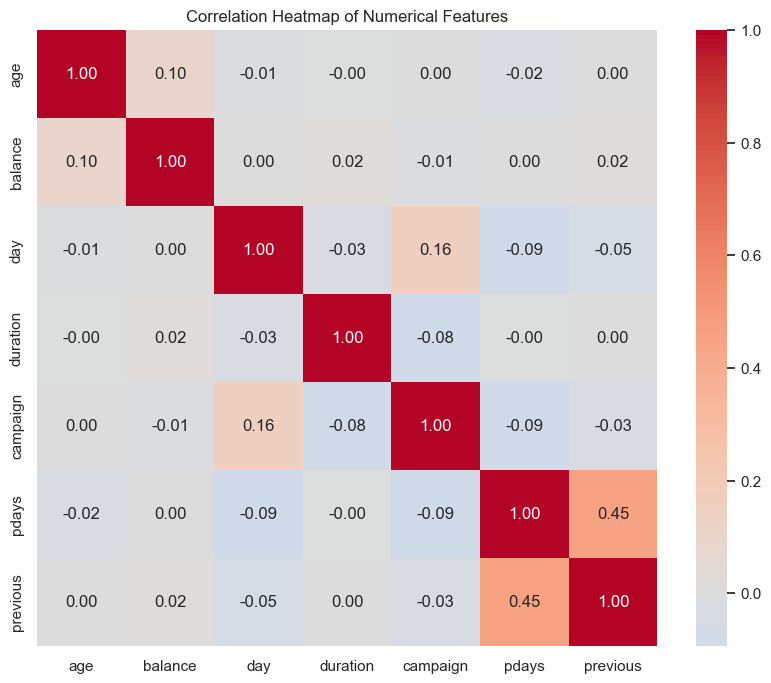

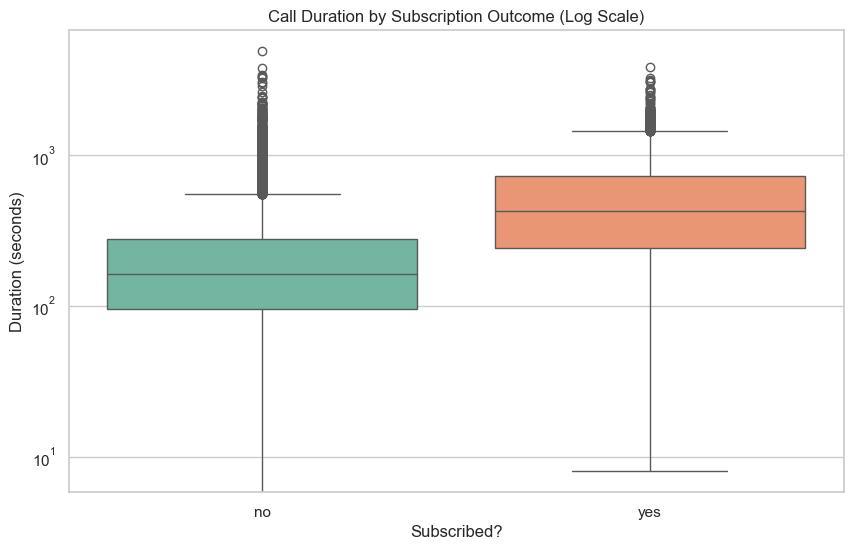

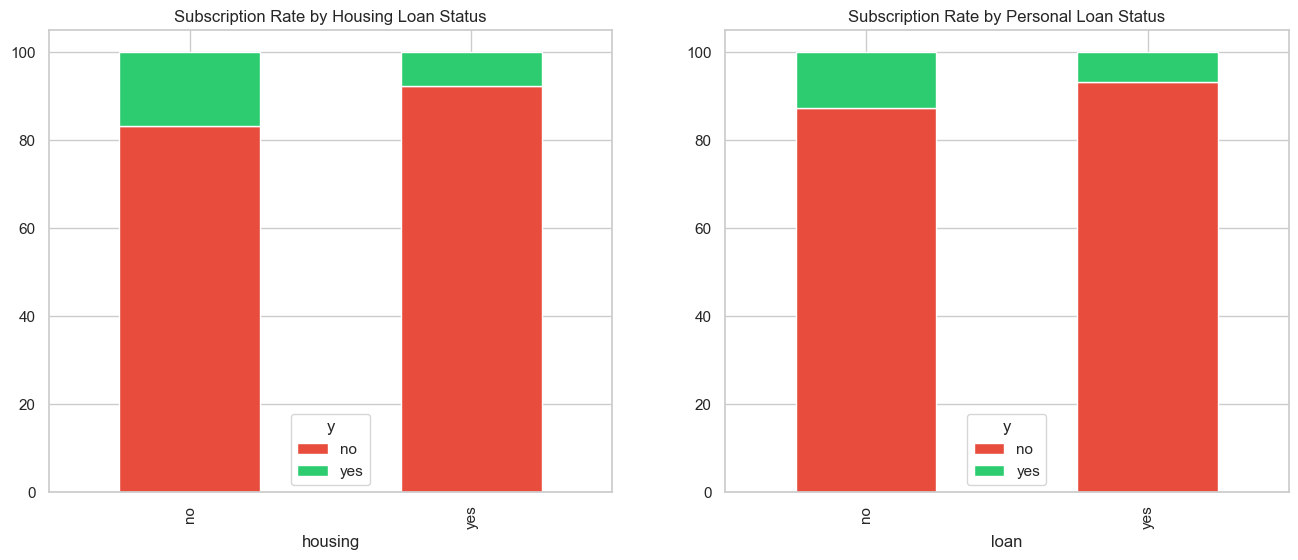

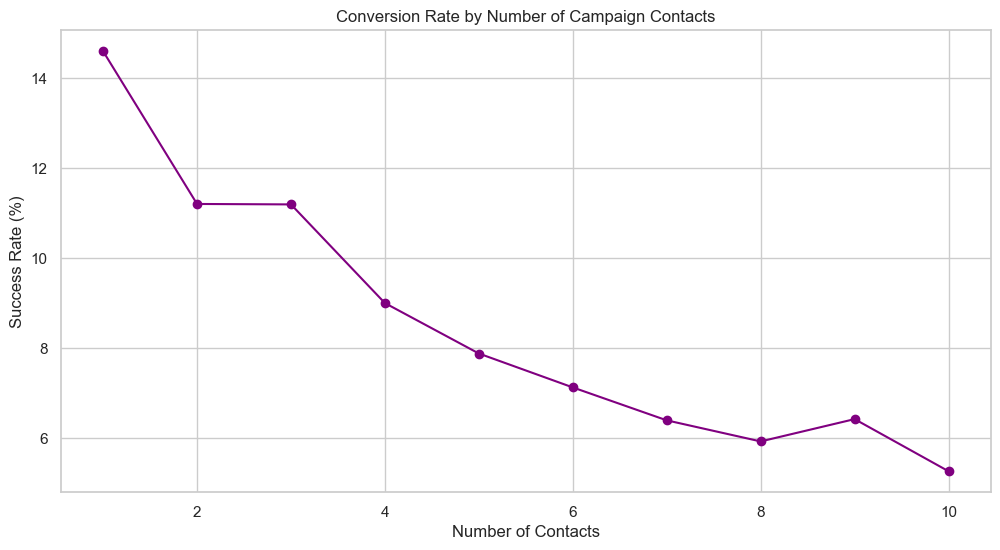

In [51]:
# 4. Advanced Insights 
plot_correlation_heatmap(train_df)
plot_duration_impact(train_df)
plot_debt_vs_conversion(train_df)
plot_campaign_efficiency(train_df)

### Preprocessing
Impute unknowns, clip outliers, log-transform skewed features and encode categoricals. Log transformation and scaling are applied selectively, as tree-based models in Phase IV do not require these steps.

In [52]:
# Ordinal encoding preserves natural ordering for education and month.
EDUCATION_ORDER = {
    'primary':   1,
    'secondary': 2,
    'tertiary':  3,
}

MONTH_ORDER = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4,
    'may': 5, 'jun': 6, 'jul': 7, 'aug': 8,
    'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12,
}

# Binary columns mapped to 0/1.
BINARY_COLS = ['default', 'housing', 'loan']

# Nominal categoricals with no natural order, one-hot encoded.
OHE_COLS = ['job', 'marital', 'contact', 'poutcome']

# Right-skewed features log-transformed. Balance is handled separately as it can be negative.
LOG_COLS = ['duration', 'campaign', 'pdays', 'previous']

In [53]:
# Applies imputation, outlier clipping, encoding and optional log transformation.

def preprocess_data(df, log_transform=True):
    df = df.copy()

    # Replace 'unknown' strings with NaN and impute using column mode.
    df.replace('unknown', np.nan, inplace=True)
    for col in df.columns:
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].mode()[0])
    assert df.isna().sum().sum() == 0, "Unexpected NaNs remain after imputation"

    # Clip outliers to 1.5*IQR bounds rather than removing them.
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != 'y']
    Q1 = df[numeric_cols].quantile(0.25)
    Q3 = df[numeric_cols].quantile(0.75)
    IQR = Q3 - Q1
    for col in numeric_cols:
        lower = Q1[col] - 1.5 * IQR[col]
        upper = Q3[col] + 1.5 * IQR[col]
        df[col] = np.clip(df[col], lower, upper)

    # Replace -1 sentinel (never contacted) with 0 regardless of log_transform.
    df['pdays'] = df['pdays'].replace(-1, 0)
    if log_transform:
        for col in LOG_COLS:
            df[col] = np.log1p(df[col])
        shift = df['balance'].min()
        if shift < 0:
            df['balance'] = df['balance'] - shift
        df['balance'] = np.log1p(df['balance'])

    # Ordinal encoding for education.
    if 'education' in df.columns:
        df['education'] = df['education'].map(EDUCATION_ORDER)

    # Cyclical encoding for month so December and January are treated as adjacent.
    month_num = df['month'].map(MONTH_ORDER)
    df['month_sin'] = np.sin(2 * np.pi * month_num / 12)
    df['month_cos'] = np.cos(2 * np.pi * month_num / 12)
    df.drop(columns=['month'], inplace=True)

    for col in BINARY_COLS:
        df[col] = df[col].map({'yes': 1, 'no': 0})

    df = pd.get_dummies(df, columns=OHE_COLS, drop_first=True, dtype=int)
    df['y'] = df['y'].map({'yes': 1, 'no': 0})

    # Contact ratio: prior contacts relative to current campaign contacts.
    df['contact_ratio'] = df['previous'] / (df['campaign'] + 1)

    return df

In [54]:
def split_and_scale(df, target='y', test_size=0.2, random_state=42, scale=True):
    X = df.drop(columns=[target])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    if scale:
        scaler = preprocessing.StandardScaler()
        X_train = pd.DataFrame(
            scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
        )
        X_test = pd.DataFrame(
            scaler.transform(X_test), columns=X_test.columns, index=X_test.index
        )

    print(f"Train: {X_train.shape}, Test: {X_test.shape}")
    print(f"Class balance (train) — 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}")

    return X_train, X_test, y_train, y_test


## Phase I — Unsupervised Structural Analysis

PCA to see how many dimensions carry the variance, then K-Means + GMM to check whether customers form natural groups that line up with the target `y`. Fit on the scaled training split only.


In [55]:
def pca_analysis(X_train, y_train, var_threshold=0.90):
    # PCA explained variance + 2D projection coloured by the target.
    pca = PCA().fit(X_train)
    cum = np.cumsum(pca.explained_variance_ratio_)
    n_comp = int(np.argmax(cum >= var_threshold) + 1)
    print(f"{X_train.shape[1]} features | {n_comp} components reach {var_threshold:.0%} variance "
          f"| first 2 PCs = {cum[1]:.1%}")

    Z = PCA(n_components=2, random_state=42).fit_transform(X_train)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    ax1.plot(range(1, len(cum) + 1), cum, marker="o")
    ax1.axhline(var_threshold, color="red", ls="--"); ax1.axvline(n_comp, color="green", ls="--")
    ax1.set(xlabel="# components", ylabel="cumulative explained variance", title="PCA explained variance")
    for lab, c, name in [(0, "lightsteelblue", "No"), (1, "crimson", "Yes")]:
        m = y_train.values == lab
        ax2.scatter(Z[m, 0], Z[m, 1], s=6, alpha=0.3, c=c, label=name)
    ax2.set(xlabel="PC1", ylabel="PC2", title="Data on first two PCs"); ax2.legend(title="Subscribed")
    plt.tight_layout(); plt.show()
    return pca, n_comp


In [56]:
def cluster_analysis(X_train, y_train, k_range=range(2, 8), sample_size=5000):
    # Pick k via K-Means silhouette and GMM BIC, then test cluster-target alignment.
    km_sil, gmm_bic = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_train)
        km_sil.append(silhouette_score(X_train, km.labels_, sample_size=sample_size, random_state=42))
        gmm_bic.append(GaussianMixture(k, covariance_type="full", random_state=42).fit(X_train).bic(X_train))

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
    a1.plot(list(k_range), km_sil, marker="o"); a1.set(title="K-Means silhouette", xlabel="k", ylabel="silhouette")
    a2.plot(list(k_range), gmm_bic, marker="o", color="darkorange"); a2.set(title="GMM BIC (lower=better)", xlabel="k", ylabel="BIC")
    plt.tight_layout(); plt.show()

    best_k = list(k_range)[int(np.argmax(km_sil))]
    print(f"Best k (K-Means silhouette) = {best_k}, silhouette = {max(km_sil):.3f}")

    labels = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(X_train)
    ct = pd.crosstab(labels, y_train.values, rownames=["cluster"], colnames=["y"])
    ct["subscribe_rate"] = ct[1] / ct.sum(axis=1)
    print(ct.round(3))
    print(f"Overall rate = {y_train.mean():.3f} | Adjusted Rand Index = "
          f"{adjusted_rand_score(y_train, labels):.4f}")
    return best_k, ct


## Evaluation metrics 
Baseline + classification metrics used to evaluate models


In [57]:
def cv_classification_metrics(model, X, y, cv):
    # Returns mean CV scores for accuracy, F1, ROC-AUC and AUPR, plus per-fold AUC for significance testing.
    scoring = {
        'accuracy': 'accuracy',
        'f1':       'f1',
        'roc_auc':  'roc_auc',
        'aupr':     'average_precision',
    }
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    return {
        'Accuracy': scores['test_accuracy'].mean(),
        'F1':       scores['test_f1'].mean(),
        'ROC-AUC':  scores['test_roc_auc'].mean(),
        'AUPR':     scores['test_aupr'].mean(),
        'Fit Time (s)': scores['fit_time'].mean(),
        '_auc_folds': scores['test_roc_auc'],
    }

In [58]:
def baseline_model(X_train, y_train, cv):
    # Always predicts the majority class. All models should outperform this to be considered useful.
    dummy = DummyClassifier(strategy='most_frequent', random_state=42)
    dummy_metrics = cv_classification_metrics(dummy, X_train, y_train, cv)
    for k, v in dummy_metrics.items():
        if not k.startswith('_'):
            print(f"  {k}: {v:.4f}")
    return dummy_metrics

## Phase II — Linear and Regularized Models
Logistic regression with a Ridge/Lasso (λ) sweep, examining how regularization shifts the coefficients.


In [59]:
def logistic_regression_unregularized_model(X_train, y_train, cv):
    # Logistic regression with effectively no regularization (C=1e6) as a linear baseline.
    lr = LogisticRegression(C=1e6, solver='saga', max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    lr_metrics = cv_classification_metrics(lr, X_train, y_train, cv)
    
    print(f"\nLogistic Regression (unregularized)")
    for k, v in lr_metrics.items():
        if not k.startswith('_'):
            print(f"  CV {k}: {v:.4f}")
            
    return lr, lr_metrics

In [60]:
def regularization_sweep(X_train, y_train, cv):
    # Sweeps lambda values for Ridge and Lasso logistic regression to study the effect of regularization.
    lambdas  = [1e-4, 1e-3, 1e-2, 0.1, 0.5, 1, 5, 10, 50, 100]
    C_values = [1/l for l in lambdas]
    
    sweep_results = []
    for C in C_values:
        r = cv_classification_metrics(
            LogisticRegression(C=C, penalty='l2', solver='saga', max_iter=1000, random_state=42),
            X_train, y_train, cv)
        l = cv_classification_metrics(
            LogisticRegression(C=C, penalty='l1', solver='saga', max_iter=1000, random_state=42),
            X_train, y_train, cv)
        sweep_results.append({
            'lambda':         1/C,
            'Ridge Accuracy': r['Accuracy'], 'Ridge F1':   r['F1'],
            'Ridge AUC':      r['ROC-AUC'],  'Ridge AUPR': r['AUPR'],
            'Lasso Accuracy': l['Accuracy'], 'Lasso F1':   l['F1'],
            'Lasso AUC':      l['ROC-AUC'],  'Lasso AUPR': l['AUPR'],
        })
    
    sweep_df = pd.DataFrame(sweep_results).set_index('lambda')
    print("\nRegularization sweep (all CV metrics):")
    print(sweep_df.round(4))
    return sweep_df, C_values

In [61]:
def plot_lambda_sweep(sweep_df, lr_metrics):
    # Grid of plots showing how Ridge and Lasso CV metrics change across lambda values.
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    plot_cols = [
        ('AUC',      'ROC-AUC'),
        ('AUPR',     'AUPR'),
        ('F1',       'F1'),
        ('Accuracy', 'Accuracy'),
    ]
    for ax, (col_suffix, ylabel) in zip(axes.flatten(), plot_cols):
        ax.plot(sweep_df.index, sweep_df[f'Ridge {col_suffix}'], marker='o', label='Ridge (L2)')
        ax.plot(sweep_df.index, sweep_df[f'Lasso {col_suffix}'], marker='s', label='Lasso (L1)')
        metric_key = 'ROC-AUC' if col_suffix == 'AUC' else ylabel
        ax.axhline(lr_metrics[metric_key], linestyle='--', color='gray', label='Unregularized')
        ax.set_xscale('log')
        ax.set_xlabel('lambda (regularization strength)')
        ax.set_ylabel(f'CV {ylabel}')
        ax.set_title(f'Effect of Regularization on {ylabel}')
        ax.legend(fontsize=8)
    plt.suptitle('Regularization Sweep: Ridge vs Lasso', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

In [62]:
def best_regularized_models(X_train, y_train, cv, C_values):
    # Fits Ridge and Lasso via LogisticRegressionCV to find the best lambda, then evaluates at that lambda.
    ridge_cv = LogisticRegressionCV(
        Cs=C_values, penalty='l2', solver='saga',
        cv=cv, scoring='roc_auc', max_iter=1000, random_state=42
    )
    ridge_cv.fit(X_train, y_train)
    # Use plain LR at best C to avoid get_params() leaking into metrics.
    ridge_best = LogisticRegression(C=ridge_cv.C_[0], penalty='l2', solver='saga',
                                     max_iter=1000, random_state=42)
    ridge_metrics = cv_classification_metrics(ridge_best, X_train, y_train, cv)
    
    print(f"\nBest Ridge  lambda={1/ridge_cv.C_[0]:.4f}")
    for k, v in ridge_metrics.items():
        if not k.startswith('_'):
            print(f"  CV {k}: {v:.4f}")

    lasso_cv = LogisticRegressionCV(
        Cs=C_values, penalty='l1', solver='saga',
        cv=cv, scoring='roc_auc', max_iter=1000, random_state=42
    )
    lasso_cv.fit(X_train, y_train)
    # Use plain LR at best C to avoid get_params() leaking into metrics.
    lasso_best = LogisticRegression(C=lasso_cv.C_[0], penalty='l1', solver='saga',
                                     max_iter=1000, random_state=42)
    lasso_metrics = cv_classification_metrics(lasso_best, X_train, y_train, cv)
    print(f"\nBest Lasso  lambda={1/lasso_cv.C_[0]:.4f}")
    for k, v in lasso_metrics.items():
        if not k.startswith('_'):
            print(f"  CV {k}: {v:.4f}")

    return ridge_cv, lasso_cv, ridge_metrics, lasso_metrics

In [63]:
def plot_coefficients(lr, ridge_cv, lasso_cv, X_train):
    # Compares coefficients across unregularized, Ridge and Lasso logistic regression.
    coef_df = pd.DataFrame({
        'Unregularized': lr.coef_[0],
        'Ridge':         ridge_cv.coef_[0],
        'Lasso':         lasso_cv.coef_[0],
    }, index=X_train.columns)
    
    n_zeroed = (coef_df['Lasso'] == 0).sum()
    print(f"\nLasso zeroed {n_zeroed}/{len(X_train.columns)} features")
    
    # Top 15 features by Ridge magnitude
    top_features = coef_df['Ridge'].abs().nlargest(15).index
    fig, ax = plt.subplots(figsize=(10, 6))
    coef_df.loc[top_features].plot(kind='barh', ax=ax)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title('Top 15 Feature Coefficients: Unregularized vs Ridge vs Lasso')
    ax.set_xlabel('Coefficient value')
    plt.tight_layout()
    plt.show()
    
    fig, axes = plt.subplots(3, 1, figsize=(20, 4))
    for ax, col in zip(axes, coef_df.columns):
        sns.heatmap(coef_df[[col]].T, annot=False, cmap='coolwarm', center=0,
                    linewidths=0.3, ax=ax, cbar=True)
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

## Phase III — Kernel Methods (SVM)
Linear, RBF and polynomial SVMs, tuned with grid search on a stratified subsample for speed.


In [64]:
def svm_default_models(X_train, y_train, cv):
    # Trains all three kernels without tuning to establish a pre-grid-search baseline.
    print("=== SVM Default Models (untuned) ===")
 
    results = {}
    for kernel, kwargs in [('linear', {}), ('rbf', {}), ('poly', {'degree': 3})]:
        svm = SVC(kernel=kernel, class_weight='balanced',
                  probability=True, random_state=42, **kwargs)
        t0 = time()
        svm.fit(X_train, y_train)
        train_time = time() - t0
 
        m = cv_classification_metrics(svm, X_train, y_train, cv)
        m['Train time (s)'] = round(train_time, 2)
        results[f'SVM {kernel} (default)'] = m
        print(f"  {kernel}: AUC={m['ROC-AUC']:.4f}  F1={m['F1']:.4f}  "
              f"Time={timedelta(seconds=train_time)}")
 
    default_df = pd.DataFrame({
        name: {k: v for k, v in m.items() if not k.startswith('_')}
        for name, m in results.items()
    }).T
    print("\nDefault SVM comparison:")
    print(default_df.round(4))

In [65]:
def svm_grid_search(X_train, y_train, cv):
    # Grid search on a 30% stratified subsample for speed. Best params are refitted on the full set in svm_best_models.
    print("\n=== SVM Grid Search ===")
 
    # 30% subsample preserving class balance via stratify.
    X_sub, _, y_sub, _ = train_test_split(X_train, y_train, train_size=0.3,
                              stratify=y_train, random_state=42)
    print(f"Subsampling to {X_sub.shape[0]} samples (30%) for speed")
 
    base_kwargs = dict(class_weight='balanced', probability=True, random_state=42)
    scoring     = dict(accuracy='accuracy', f1='f1',
                       roc_auc='roc_auc', aupr='average_precision')
 
    # Linear
    t0 = time()
    gs_linear = GridSearchCV(
        SVC(kernel='linear', **base_kwargs),
        param_grid={'C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10]},
        scoring=scoring, refit='roc_auc', cv=cv, n_jobs=-1
    ).fit(X_sub, y_sub)
    print(f"\nLinear -- {timedelta(seconds=time()-t0)}  "
          f"best: {gs_linear.best_params_}  AUC: {gs_linear.best_score_:.4f}")
 
    # RBF
    t0 = time()
    gs_rbf = GridSearchCV(
        SVC(kernel='rbf', **base_kwargs),
        param_grid={'C':     [0.1, 1, 5, 10, 50],
                    'gamma': ['scale', 'auto', 0.01, 0.001]},
        scoring=scoring, refit='roc_auc', cv=cv, n_jobs=-1
    ).fit(X_sub, y_sub)
    print(f"RBF    -- {timedelta(seconds=time()-t0)}  "
          f"best: {gs_rbf.best_params_}  AUC: {gs_rbf.best_score_:.4f}")
 
    # Polynomial
    t0 = time()
    gs_poly = GridSearchCV(
        SVC(kernel='poly', **base_kwargs),
        param_grid={'C':      [0.1, 1, 5, 10],
                    'degree': [2, 3, 5]},
        scoring=scoring, refit='roc_auc', cv=cv, n_jobs=-1
    ).fit(X_sub, y_sub)
    print(f"Poly   -- {timedelta(seconds=time()-t0)}  "
          f"best: {gs_poly.best_params_}  AUC: {gs_poly.best_score_:.4f}")
 
    return gs_linear, gs_rbf, gs_poly

In [66]:
def svm_best_models(gs_linear, gs_rbf, gs_poly, X_train, y_train, cv):
    # Refits best params from grid search on the full training set and collects CV metrics.
    print("\n=== SVM Best Models (full training set) ===")
 
    base_kwargs = dict(class_weight='balanced', probability=True, random_state=42)
    models, metrics_out = {}, {}
 
    configs = [
        ('SVM Linear', 'linear', gs_linear.best_params_),
        ('SVM RBF',    'rbf',    gs_rbf.best_params_),
        ('SVM Poly',   'poly',   gs_poly.best_params_),
    ]
 
    for name, kernel, params in configs:
        svm = SVC(kernel=kernel, **base_kwargs, **params)
        t0 = time()
        svm.fit(X_train, y_train)
        train_time = time() - t0
 
        m = cv_classification_metrics(svm, X_train, y_train, cv)
        m['Train time (s)'] = round(train_time, 2)
 
        models[name]      = svm
        metrics_out[name] = m
 
        print(f"\n{name}  params={params}")
        for k, v in m.items():
            if not k.startswith('_'):
                print(f"  CV {k}: {v:.4f}" if k != 'Train time (s)'
                      else f"  Train time: {timedelta(seconds=v)}")
 
    return (models['SVM Linear'], models['SVM RBF'],  models['SVM Poly'],
            metrics_out['SVM Linear'], metrics_out['SVM RBF'], metrics_out['SVM Poly'])

In [67]:
def plot_svm_comparison(m_linear, m_rbf, m_poly):
    # Bar charts comparing CV metrics and training time across the three SVM kernels.
    metric_keys = ['Accuracy', 'F1', 'ROC-AUC', 'AUPR']
    kernels     = ['Linear', 'RBF', 'Polynomial']
    values      = [[m_linear[k], m_rbf[k], m_poly[k]] for k in metric_keys]
 
    x     = np.arange(len(kernels))
    width = 0.18
 
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, (metric, vals) in enumerate(zip(metric_keys, values)):
        ax.bar(x + i * width, vals, width, label=metric)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(kernels)
    ax.set_ylabel('CV Score')
    ax.set_ylim(0, 1)
    ax.set_title('SVM Kernel Comparison: All CV Metrics')
    ax.legend()
    plt.tight_layout()
    plt.show()
 
    # Training time comparison
    times = [m_linear['Train time (s)'], m_rbf['Train time (s)'], m_poly['Train time (s)']]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(kernels, times, color=['steelblue', 'coral', 'mediumseagreen'])
    ax.set_ylabel('Training time (seconds)')
    ax.set_title('SVM Training Time by Kernel')
    plt.tight_layout()
    plt.show()

## Phase IV — Ensemble Methods
Random Forest (bagging) and Gradient Boosting (boosting); compare metrics, training time and feature importance.


In [68]:
def train_ensemble_models(X_train, y_train, cv):
    # Tunes Random Forest and Gradient Boosting via randomized search and returns the best models.
    print("\nTraining and Tuning Random Forest...")
    rf_params = {
        'n_estimators': [100, 200],
        'max_depth': [10, 15, None],
        'min_samples_split': [5, 10]
    }
    rf_search = RandomizedSearchCV(
        RandomForestClassifier(random_state=42, class_weight='balanced'),
        rf_params, n_iter=4, cv=cv, scoring='roc_auc', n_jobs=-1, random_state=42
    )
    rf_search.fit(X_train, y_train)
    rf_best = rf_search.best_estimator_
    print(f"  Best RF Params: {rf_search.best_params_}")
    rf_metrics = cv_classification_metrics(rf_best, X_train, y_train, cv)
    for k, v in rf_metrics.items():
        if not k.startswith('_'):
            print(f"  CV {k}: {v:.4f}")

    print("\nTraining and Tuning Gradient Boosting...")
    gb_params = {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 4, 5]
    }
    gb_search = RandomizedSearchCV(
        GradientBoostingClassifier(random_state=42),
        gb_params, n_iter=4, cv=cv, scoring='roc_auc', n_jobs=-1, random_state=42
    )
    gb_search.fit(X_train, y_train)
    gb_best = gb_search.best_estimator_
    print(f"  Best GB Params: {gb_search.best_params_}")
    gb_metrics = cv_classification_metrics(gb_best, X_train, y_train, cv)
    for k, v in gb_metrics.items():
        if not k.startswith('_'):
            print(f"  CV {k}: {v:.4f}")

    return rf_best, gb_best, rf_metrics, gb_metrics


def plot_ensemble_feature_importance(rf, gb, X_train):
    # Bar charts showing the top 15 features by importance for each ensemble model.
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    rf_importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
    rf_importances.sort_values().plot(kind='barh', ax=ax1, color='#2ecc71')
    ax1.set_title('Top 15 Features: Random Forest')
    ax1.set_xlabel('Gini Importance')

    gb_importances = pd.Series(gb.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
    gb_importances.sort_values().plot(kind='barh', ax=ax2, color='#e74c3c')
    ax2.set_title('Top 15 Features: Gradient Boosting')
    ax2.set_xlabel('Friedman MSE Importance')

    plt.tight_layout()
    plt.show()

### k-Nearest Neighbours & Neural Network (MLP)
Two further models for the comparison: a tuned distance-weighted k-NN (instance-based) and an MLP neural network with early stopping.


In [69]:
def train_knn_and_mlp(X_train, y_train, cv):
    # Tunes k-NN and MLP via grid search and returns the best models with CV metrics.

    # k-NN: tune neighbourhood size and weighting strategy.
    print("\nTuning k-NN...")
    knn_search = GridSearchCV(
        KNeighborsClassifier(),
        {"n_neighbors": [15, 25, 51, 75], "weights": ["uniform", "distance"]},
        cv=cv, scoring="roc_auc", n_jobs=-1,
    ).fit(X_train, y_train)
    knn = knn_search.best_estimator_
    print(f"  Best k-NN params: {knn_search.best_params_}")
    knn_metrics = cv_classification_metrics(knn, X_train, y_train, cv)
    for k, v in knn_metrics.items():
        if not k.startswith("_"):
            print(f"  CV {k}: {v:.4f}")

    # MLP: early stopping guards against overfitting.
    print("\nTuning Neural Network (MLP)...")
    mlp_search = GridSearchCV(
        MLPClassifier(max_iter=300, early_stopping=True, random_state=42),
        {"hidden_layer_sizes": [(64,), (64, 32)], "alpha": [1e-4, 1e-3]},
        cv=cv, scoring="roc_auc", n_jobs=-1,
    ).fit(X_train, y_train)
    mlp = mlp_search.best_estimator_
    print(f"  Best MLP params: {mlp_search.best_params_}")
    mlp_metrics = cv_classification_metrics(mlp, X_train, y_train, cv)
    for k, v in mlp_metrics.items():
        if not k.startswith("_"):
            print(f"  CV {k}: {v:.4f}")

    return knn, mlp, knn_metrics, mlp_metrics

### Class Imbalance: Sampling Strategies
Compares no sampling, class_weight, SMOTE and random undersampling on logistic regression and random forest. Samplers are fitted inside CV folds to prevent leakage.

In [70]:
def compare_sampling_strategies(X_train, y_train, cv):
    #Compare imbalance strategies on a linear (LR) and a tree (RF) model.
    estimators = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    }
    strategies = ["None", "class_weight", "SMOTE (over)", "Undersample"]
    samplers = {"SMOTE (over)": SMOTE(random_state=42),
                "Undersample":  RandomUnderSampler(random_state=42)}

    rows = []
    for est_name, base in estimators.items():
        for strat in strategies:
            if strat == "class_weight":
                model = clone(base).set_params(class_weight="balanced")
            elif strat == "None":
                model = clone(base)
            else:
                model = ImbPipeline([("sampler", samplers[strat]), ("clf", clone(base))])
            m = cv_classification_metrics(model, X_train, y_train, cv)
            rows.append({"Model": est_name, "Strategy": strat,
                         "F1": m["F1"], "ROC-AUC": m["ROC-AUC"], "AUPR": m["AUPR"]})
            print(f"  {est_name:20} {strat:14} F1={m['F1']:.3f}  AUC={m['ROC-AUC']:.3f}  AUPR={m['AUPR']:.3f}")

    results = pd.DataFrame(rows)

    # F1 is the imbalance-sensitive metric; AUC/AUPR are threshold-independent
    pivot = results.pivot(index="Strategy", columns="Model", values="F1").loc[strategies]
    ax = pivot.plot(kind="bar", figsize=(10, 5))
    ax.set_ylabel("CV F1"); ax.set_title("Effect of imbalance strategy on F1")
    ax.set_xticklabels(strategies, rotation=0); ax.legend(title="Model")
    plt.tight_layout(); plt.show()
    return results


Dataset loaded: 45211 rows, 17 columns.
Train: (36168, 29), Test: (9043, 29)
Class balance (train) — 0: 31937, 1: 4231
  Logistic Regression  None           F1=0.374  AUC=0.881  AUPR=0.514
  Logistic Regression  class_weight   F1=0.480  AUC=0.882  AUPR=0.509
  Logistic Regression  SMOTE (over)   F1=0.483  AUC=0.881  AUPR=0.506
  Logistic Regression  Undersample    F1=0.478  AUC=0.881  AUPR=0.508
  Random Forest        None           F1=0.456  AUC=0.916  AUPR=0.569
  Random Forest        class_weight   F1=0.423  AUC=0.917  AUPR=0.571
  Random Forest        SMOTE (over)   F1=0.543  AUC=0.914  AUPR=0.539
  Random Forest        Undersample    F1=0.539  AUC=0.915  AUPR=0.544


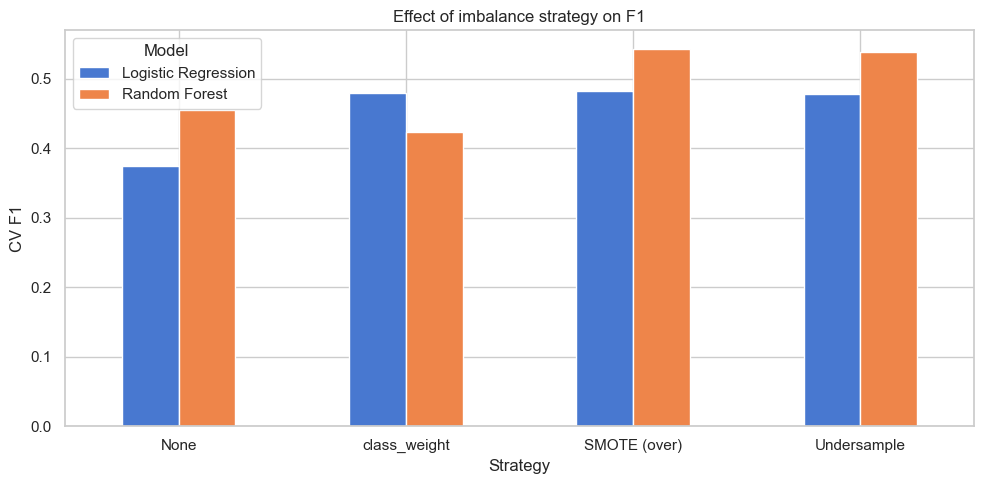

,Model,Strategy,F1,ROC-AUC,AUPR
0,Logistic Regression,None,0.373987,0.880987,0.513741
1,Logistic Regression,class_weight,0.479855,0.881616,0.509247
2,Logistic Regression,SMOTE (over),0.482873,0.880666,0.505867
3,Logistic Regression,Undersample,0.477672,0.881290,0.507756
4,Random Forest,None,0.455593,0.915997,0.569171
5,Random Forest,class_weight,0.422896,0.917208,0.570697
6,Random Forest,SMOTE (over),0.542589,0.914085,0.538710
7,Random Forest,Undersample,0.538833,0.915248,0.543522


In [71]:
def sampling_experiment():
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    X_train, _, y_train, _ = split_and_scale(preprocess_data(load_data()))
    return compare_sampling_strategies(X_train, y_train, cv)


sampling_experiment()


## Phase V — Model Selection and Validation
Rank all models by cross-validated metrics, test the top gap with a paired t-test, and evaluate the winner on the held-out test set.


In [72]:
def model_comparison(metrics):
    # Prints a comparison table of all models and returns them ranked by CV ROC-AUC.
    comparison_df = pd.DataFrame({
        name: {k: v for k, v in m.items() if not k.startswith('_')}
        for name, m in metrics.items()
    }).T

    print("\n--- Model Comparison (CV metrics & Training Time) ---")
    print(comparison_df.round(4))

    best_name = comparison_df['ROC-AUC'].idxmax()
    print(f"\nSelected model (highest CV AUC): {best_name}")
    return comparison_df['ROC-AUC'].sort_values(ascending=False)

In [73]:
def paired_t_test_on_auc(metrics, sorted_models):
    # Paired t-test on per-fold AUC scores between the best and runner-up model.
    best_name = sorted_models.index[0]
    runner_up = sorted_models.index[1]

    best_folds   = metrics[best_name]['_auc_folds']
    runner_folds = metrics[runner_up]['_auc_folds']

    t_stat, p_val = stats.ttest_rel(best_folds, runner_folds)
    print(f"\nPaired t-test: {best_name} vs {runner_up}")
    print(f"  t={t_stat:.4f}, p={p_val:.4f}")
    if p_val < 0.05:
        print("  Difference is statistically significant (p < 0.05)")
    else:
        print("  No significant difference (p >= 0.05) --> models are comparable")

In [74]:
def final_evaluation(best_name, models, X_test, y_test):
    # Evaluates the selected model on the held-out test set with metrics and curves.
    best_model = models[best_name]

    y_pred       = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]

    print(f"\n--- Test Set Results ({best_name}) ---")
    print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"  F1:       {f1_score(y_test, y_pred):.4f}")
    print(f"  ROC-AUC:  {roc_auc_score(y_test, y_pred_proba):.4f}")
    print(f"  AUPR:     {average_precision_score(y_test, y_pred_proba):.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['No', 'Yes'])}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=ax1, name=best_name)
    ax1.plot([0, 1], [0, 1], 'k--', label='Random baseline')
    ax1.set_title('ROC Curve (Test Set)')
    ax1.legend()
    PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test, ax=ax2, name=best_name)
    ax2.set_title('Precision-Recall Curve (Test Set)')
    plt.suptitle(f'Final Evaluation: {best_name}', fontsize=13)
    plt.tight_layout()
    plt.show()

In [75]:
# Stratified CV preserves the ~88/12 class balance in every fold.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def complete_pipeline():
    train_df = load_data()

    # Phases I, II, III: log transformed and scaled.
    clean_df = preprocess_data(train_df, log_transform=True)
    X_train, X_test, y_train, y_test = split_and_scale(clean_df, scale=True)

    # Phase IV: no log transform, no scaling (tree-based models).
    clean_df_trees = preprocess_data(train_df, log_transform=False)
    X_train_trees, X_test_trees, y_train_trees, _ = split_and_scale(clean_df_trees, scale=False)

    models, metrics = {}, {}

    # Phase I: unsupervised analysis.
    pca_analysis(X_train, y_train)
    cluster_analysis(X_train, y_train)

    # Phase II: linear models.
    dummy = DummyClassifier(strategy='most_frequent', random_state=42).fit(X_train, y_train)
    models['Baseline'], metrics['Baseline'] = dummy, baseline_model(X_train, y_train, cv)

    lr, lr_metrics = logistic_regression_unregularized_model(X_train, y_train, cv)
    models['LR (unreg)'], metrics['LR (unreg)'] = lr, lr_metrics

    sweep_df, C_values = regularization_sweep(X_train, y_train, cv)
    plot_lambda_sweep(sweep_df, lr_metrics)
    ridge_cv, lasso_cv, ridge_metrics, lasso_metrics = best_regularized_models(X_train, y_train, cv, C_values)
    plot_coefficients(lr, ridge_cv, lasso_cv, X_train)
    models['Ridge'], metrics['Ridge'] = ridge_cv, ridge_metrics
    models['Lasso'], metrics['Lasso'] = lasso_cv, lasso_metrics

    # Phase III: SVM.
    svm_default_models(X_train, y_train, cv)
    gs_linear, gs_rbf, gs_poly = svm_grid_search(X_train, y_train, cv)
    svm = svm_best_models(gs_linear, gs_rbf, gs_poly, X_train, y_train, cv)
    svm_linear, svm_rbf, svm_poly, svm_linear_metrics, svm_rbf_metrics, svm_poly_metrics = svm
    plot_svm_comparison(svm_linear_metrics, svm_rbf_metrics, svm_poly_metrics)
    models['SVM Linear'], metrics['SVM Linear'] = svm_linear, svm_linear_metrics
    models['SVM RBF'],    metrics['SVM RBF']    = svm_rbf, svm_rbf_metrics
    models['SVM Poly'],   metrics['SVM Poly']   = svm_poly, svm_poly_metrics

    # Phase IV: ensembles (unscaled, untransformed).
    rf, gb, rf_metrics, gb_metrics = train_ensemble_models(X_train_trees, y_train_trees, cv)
    plot_ensemble_feature_importance(rf, gb, X_train_trees)
    models['Rand Forest'], metrics['Rand Forest'] = rf, rf_metrics
    models['Grad Boost'],  metrics['Grad Boost']  = gb, gb_metrics

    # k-NN and neural network (scaled, same as phases II and III).
    knn, mlp, knn_metrics, mlp_metrics = train_knn_and_mlp(X_train, y_train, cv)
    models['k-NN'], metrics['k-NN'] = knn, knn_metrics
    models['Neural Net'], metrics['Neural Net'] = mlp, mlp_metrics

    # Sampling strategy comparison.
    compare_sampling_strategies(X_train, y_train, cv)

    # Phase V: model comparison, significance test, final evaluation.
    sorted_models = model_comparison(metrics)
    paired_t_test_on_auc(metrics, sorted_models)

    # Use the correct test set depending on whether the best model is tree-based.
    tree_models = ['Rand Forest', 'Grad Boost']
    best_name = sorted_models.index[0]
    X_test_final = X_test_trees if best_name in tree_models else X_test
    final_evaluation(best_name, models, X_test_final, y_test)

    return models, metrics, sorted_models

Dataset loaded: 45211 rows, 17 columns.
Train: (36168, 29), Test: (9043, 29)
Class balance (train) — 0: 31937, 1: 4231
Train: (36168, 29), Test: (9043, 29)
Class balance (train) — 0: 31937, 1: 4231
29 features | 20 components reach 90% variance | first 2 PCs = 17.2%


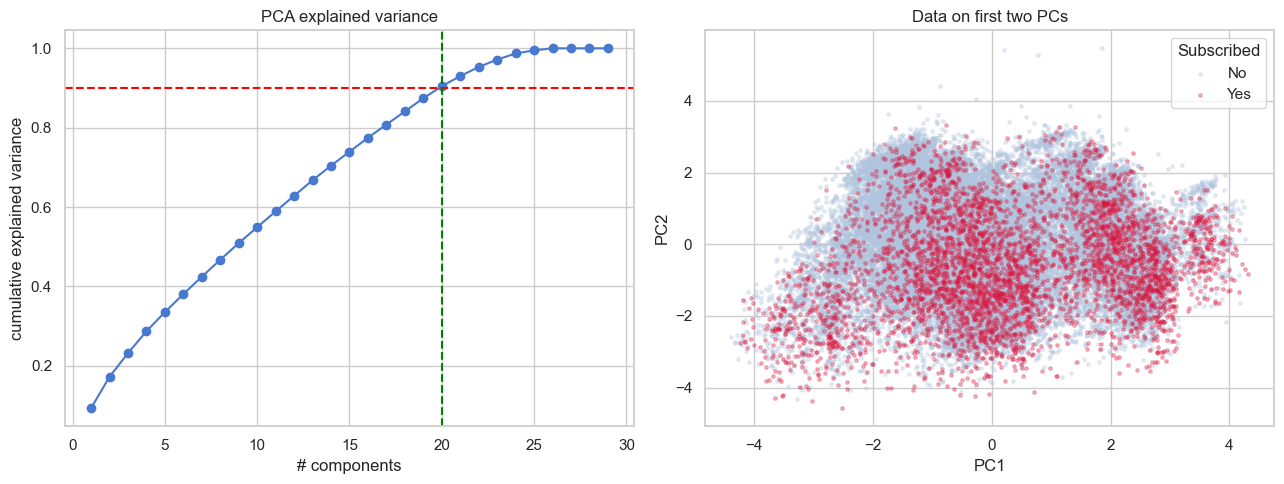

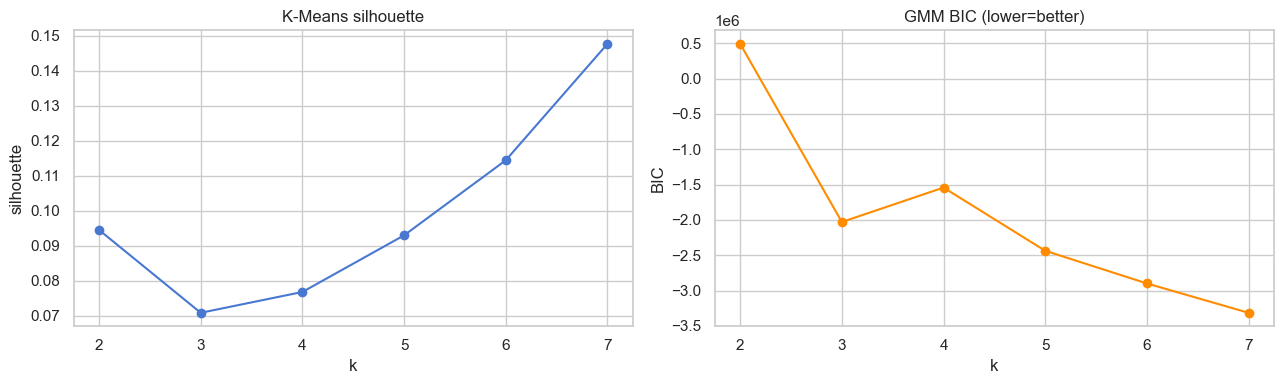

Best k (K-Means silhouette) = 7, silhouette = 0.148
y            0     1  subscribe_rate
cluster                             
0         3050   298           0.089
1        12085  1501           0.110
2          539   219           0.289
3         7531   598           0.074
4         6470  1041           0.139
5          866   158           0.154
6         1396   416           0.230
Overall rate = 0.117 | Adjusted Rand Index = 0.0107
  Accuracy: 0.8830
  F1: 0.0000
  ROC-AUC: 0.5000
  AUPR: 0.1170
  Fit Time (s): 0.0016

Logistic Regression (unregularized)
  CV Accuracy: 0.8957
  CV F1: 0.3739
  CV ROC-AUC: 0.8810
  CV AUPR: 0.5138
  CV Fit Time (s): 0.0555

Regularization sweep (all CV metrics):
          Ridge Accuracy  Ridge F1  Ridge AUC  Ridge AUPR  Lasso Accuracy  \
lambda                                                                      
0.0001            0.8957    0.3739     0.8810      0.5138          0.8957   
0.0010            0.8957    0.3739     0.8810      0.5138       

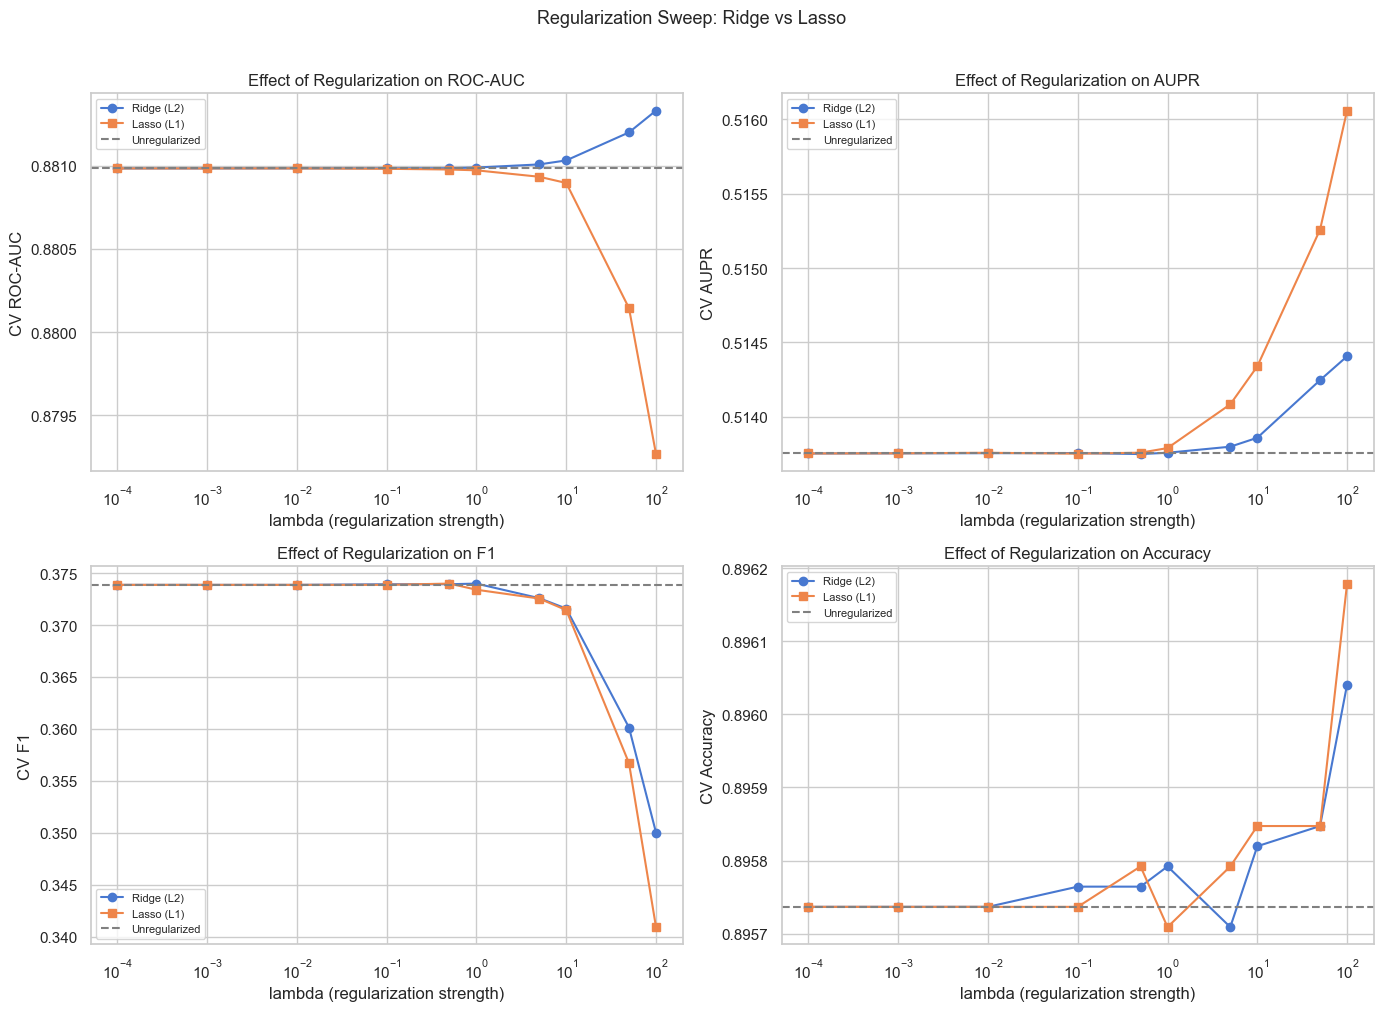


Best Ridge  lambda=100.0000
  CV Accuracy: 0.8960
  CV F1: 0.3500
  CV ROC-AUC: 0.8813
  CV AUPR: 0.5144
  CV Fit Time (s): 0.0525

Best Lasso  lambda=0.0100
  CV Accuracy: 0.8957
  CV F1: 0.3739
  CV ROC-AUC: 0.8810
  CV AUPR: 0.5138
  CV Fit Time (s): 0.0800

Lasso zeroed 3/29 features


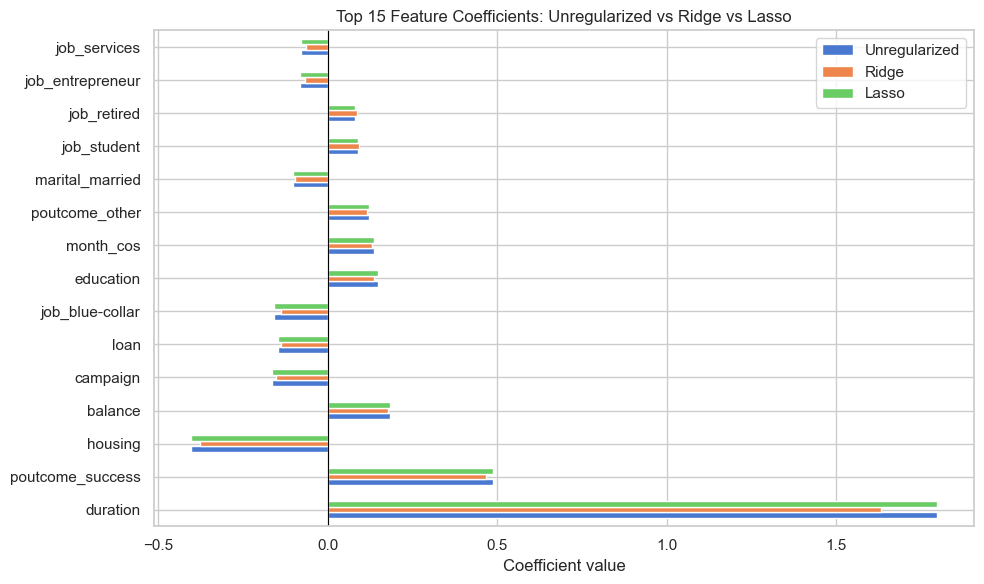

/var/folders/ls/1wdsysgs1v18dvs6sj0dbplh0000gn/T/ipykernel_81845/1479927683.py:27: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


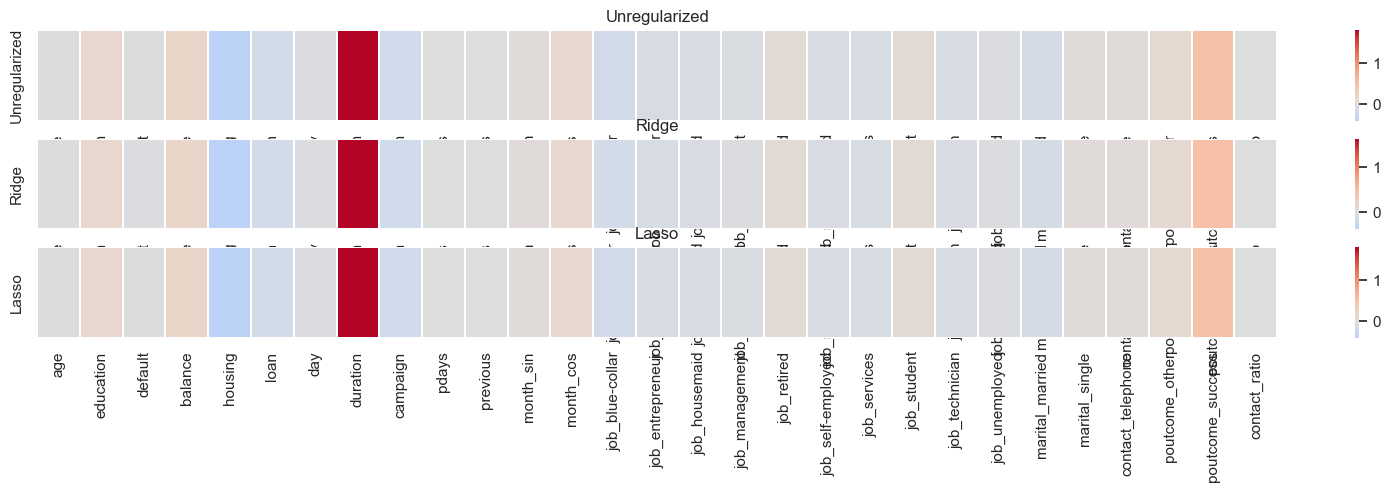

=== SVM Default Models (untuned) ===
  linear: AUC=0.8810  F1=0.4710  Time=0:01:16.013673
  rbf: AUC=0.8979  F1=0.5125  Time=0:01:14.570588
  poly: AUC=0.8872  F1=0.5115  Time=0:00:56.344659

Default SVM comparison:
                      Accuracy      F1  ROC-AUC    AUPR  Fit Time (s)  \
SVM linear (default)    0.7783  0.4710   0.8810  0.5084       47.8957   
SVM rbf (default)       0.8097  0.5125   0.8979  0.4867       43.1703   
SVM poly (default)      0.8168  0.5115   0.8872  0.4940       36.7225   

                      Train time (s)  
SVM linear (default)           76.01  
SVM rbf (default)              74.57  
SVM poly (default)             56.34  

=== SVM Grid Search ===
Subsampling to 10850 samples (30%) for speed

Linear -- 0:02:08.900179  best: {'C': 0.001}  AUC: 0.8763
RBF    -- 0:03:44.589468  best: {'C': 5, 'gamma': 0.01}  AUC: 0.8885
Poly   -- 0:01:58.143130  best: {'C': 0.1, 'degree': 3}  AUC: 0.8633

=== SVM Best Models (full training set) ===

SVM Linear  params={'C

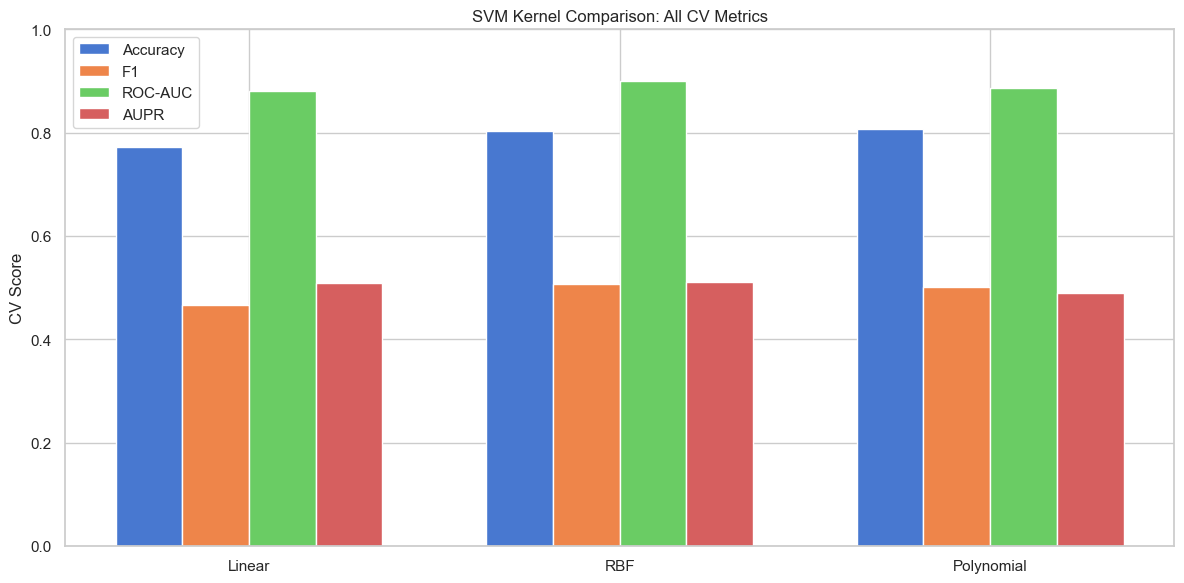

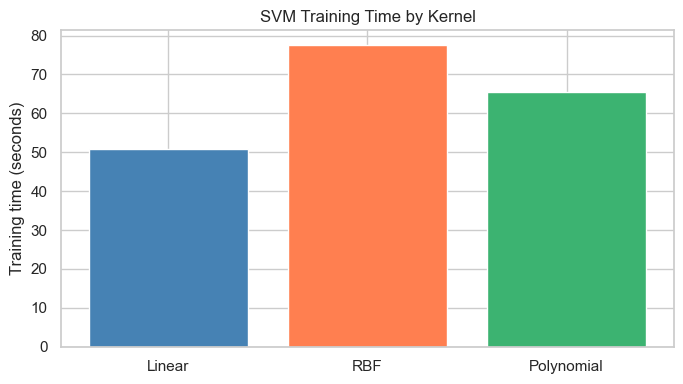


Training and Tuning Random Forest...
  Best RF Params: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': None}
  CV Accuracy: 0.9000
  CV F1: 0.5328
  CV ROC-AUC: 0.9217
  CV AUPR: 0.5814
  CV Fit Time (s): 2.7530

Training and Tuning Gradient Boosting...
  Best GB Params: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}
  CV Accuracy: 0.9040
  CV F1: 0.5109
  CV ROC-AUC: 0.9242
  CV AUPR: 0.5938
  CV Fit Time (s): 3.4313


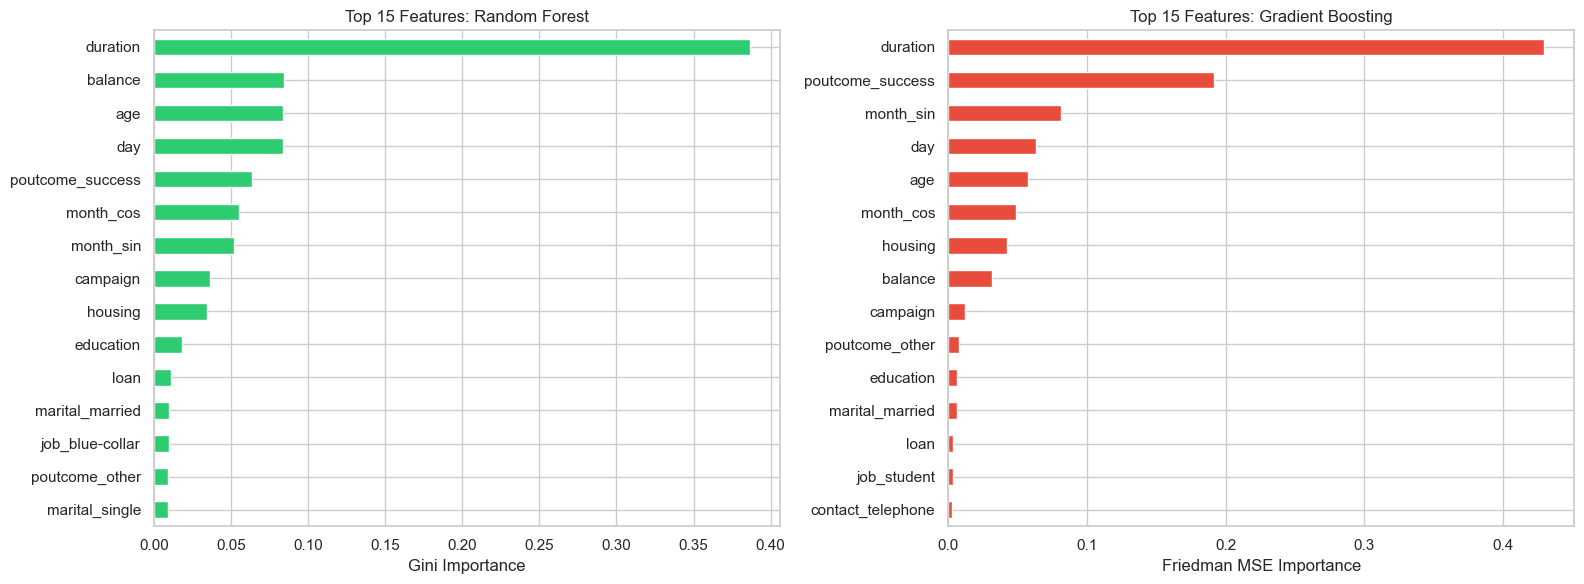


Tuning k-NN...
  Best k-NN params: {'n_neighbors': 75, 'weights': 'distance'}
  CV Accuracy: 0.8937
  CV F1: 0.2765
  CV ROC-AUC: 0.8591
  CV AUPR: 0.4638
  CV Fit Time (s): 0.0054

Tuning Neural Network (MLP)...
  Best MLP params: {'alpha': 0.0001, 'hidden_layer_sizes': (64, 32)}
  CV Accuracy: 0.8962
  CV F1: 0.4043
  CV ROC-AUC: 0.8978
  CV AUPR: 0.5411
  CV Fit Time (s): 1.0403
  Logistic Regression  None           F1=0.374  AUC=0.881  AUPR=0.514
  Logistic Regression  class_weight   F1=0.480  AUC=0.882  AUPR=0.509
  Logistic Regression  SMOTE (over)   F1=0.483  AUC=0.881  AUPR=0.506
  Logistic Regression  Undersample    F1=0.478  AUC=0.881  AUPR=0.508
  Random Forest        None           F1=0.456  AUC=0.916  AUPR=0.569
  Random Forest        class_weight   F1=0.423  AUC=0.917  AUPR=0.571
  Random Forest        SMOTE (over)   F1=0.543  AUC=0.914  AUPR=0.539
  Random Forest        Undersample    F1=0.539  AUC=0.915  AUPR=0.544


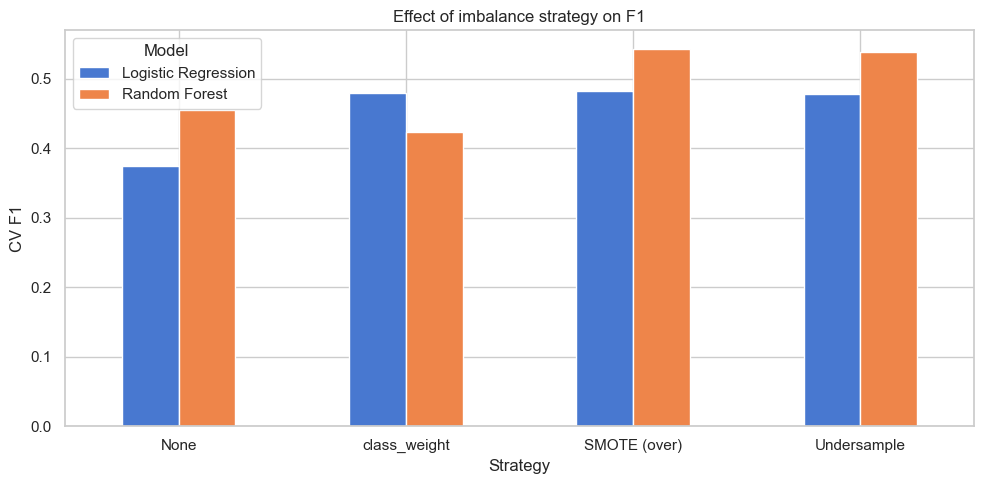


--- Model Comparison (CV metrics & Training Time) ---
             Accuracy      F1  ROC-AUC    AUPR  Fit Time (s)  Train time (s)
Baseline       0.8830  0.0000   0.5000  0.1170        0.0016             NaN
LR (unreg)     0.8957  0.3739   0.8810  0.5138        0.0555             NaN
Ridge          0.8960  0.3500   0.8813  0.5144        0.0525             NaN
Lasso          0.8957  0.3739   0.8810  0.5138        0.0800             NaN
SVM Linear     0.7725  0.4665   0.8810  0.5084       34.8696           50.83
SVM RBF        0.8039  0.5068   0.9000  0.5115       45.0795           77.46
SVM Poly       0.8080  0.5010   0.8862  0.4898       40.7239           65.37
Rand Forest    0.9000  0.5328   0.9217  0.5814        2.7530             NaN
Grad Boost     0.9040  0.5109   0.9242  0.5938        3.4313             NaN
k-NN           0.8937  0.2765   0.8591  0.4638        0.0054             NaN
Neural Net     0.8962  0.4043   0.8978  0.5411        1.0403             NaN

Selected model (high

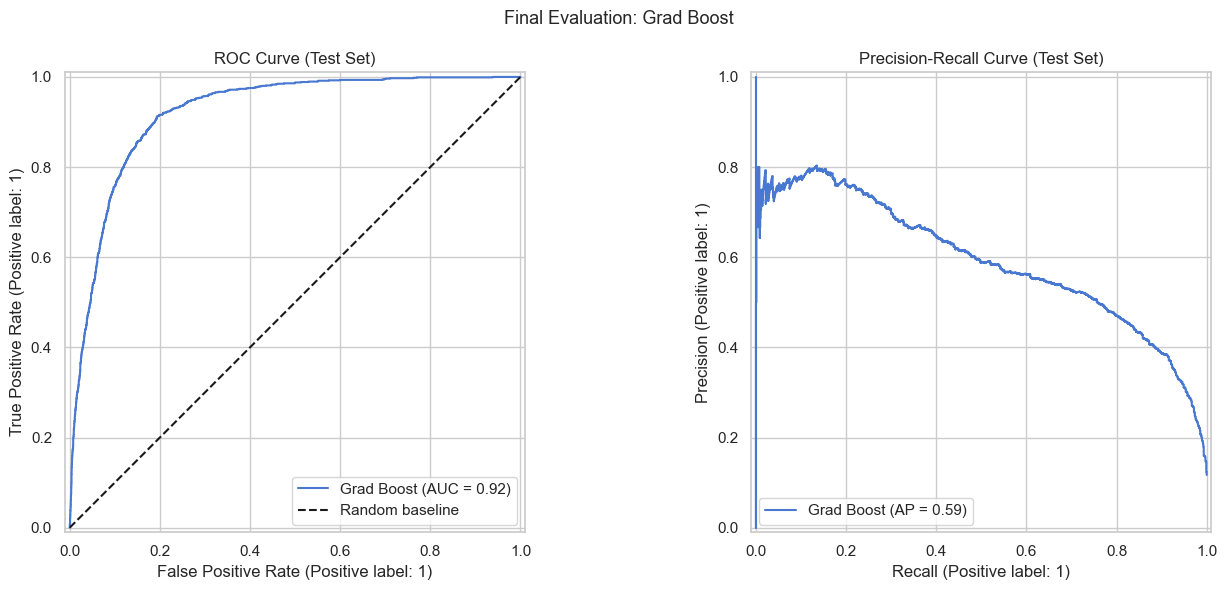

({'Baseline': DummyClassifier(random_state=42, strategy='most_frequent'),
  'LR (unreg)': LogisticRegression(C=1000000.0, max_iter=1000, random_state=42, solver='saga'),
  'Ridge': LogisticRegressionCV(Cs=[10000.0, 1000.0, 100.0, 10.0, 2.0, 1.0, 0.2, 0.1, 0.02,
                           0.01],
                       cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                       max_iter=1000, random_state=42, scoring='roc_auc',
                       solver='saga'),
  'Lasso': LogisticRegressionCV(Cs=[10000.0, 1000.0, 100.0, 10.0, 2.0, 1.0, 0.2, 0.1, 0.02,
                           0.01],
                       cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                       max_iter=1000, penalty='l1', random_state=42,
                       scoring='roc_auc', solver='saga'),
  'SVM Linear': SVC(C=0.001, class_weight='balanced', kernel='linear', probability=True,
      random_state=42),
  'SVM RBF': SVC(C=5, class_weight='balanced', gamma=

In [76]:
complete_pipeline()